Use of DeBERTa NLI on r/dubai to extract real estate posts

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Dubai_Real_Estate_Data/Prajwal final reddit"
posts_clean = pd.read_csv(f"{file_path}/dubai_posts.csv", low_memory=False)
comments_clean = pd.read_csv(f"{file_path}/dubai_comments.csv", low_memory=False)

In [ ]:
gold1 = pd.read_csv("/content/drive/MyDrive/Dubai_Real_Estate_Data/Prajwal final reddit/dubaiposts_gold_sample1.csv")

In [ ]:
!pip install transformers sentencepiece

In [ ]:
from transformers import pipeline

classifier_deberta = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-base-zeroshot-v2.0",
    device=0
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [ ]:
candidate_labels = [
    "real estate",
    "not real estate"
]

In [ ]:
scores = []

for text in gold1["post_text"].fillna(""):

    result = classifier_deberta(
        text[:1024],
        candidate_labels
    )

    real_estate_score = result["scores"][
        result["labels"].index("real estate")
    ]

    scores.append(real_estate_score)

gold1["deberta_score"] = scores

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
gold1[["deberta_score"]].head()

,deberta_score
0,0.088820
1,0.000433
2,0.000230
3,0.000247
4,0.000219


In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds:

    preds = (
        gold1["deberta_score"] >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            gold1["actual_label"],
            preds
        ),
        "precision": precision_score(
            gold1["actual_label"],
            preds,
            zero_division=0
        ),
        "recall": recall_score(
            gold1["actual_label"],
            preds,
            zero_division=0
        ),
        "f1": f1_score(
            gold1["actual_label"],
            preds,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)
results_df

,threshold,accuracy,precision,recall,f1
0,0.3,0.958,0.657895,0.757576,0.704225
1,0.4,0.958,0.657895,0.757576,0.704225
2,0.5,0.954,0.638889,0.696970,0.666667
3,0.6,0.954,0.638889,0.696970,0.666667
4,0.7,0.954,0.638889,0.696970,0.666667


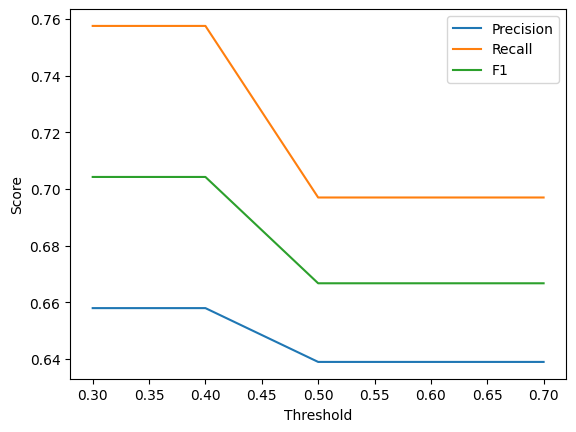

In [ ]:
import matplotlib.pyplot as plt

plt.plot(
    results_df["threshold"],
    results_df["precision"],
    label="Precision"
)

plt.plot(
    results_df["threshold"],
    results_df["recall"],
    label="Recall"
)

plt.plot(
    results_df["threshold"],
    results_df["f1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

<Axes: >

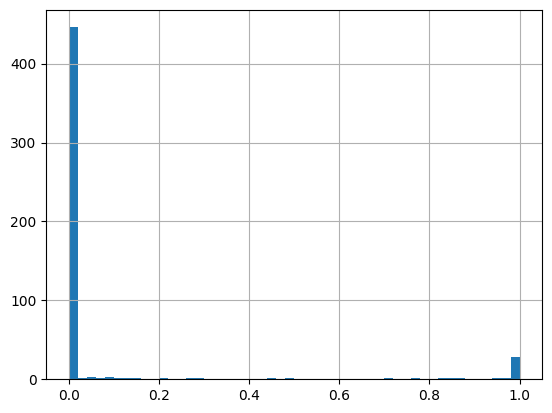

In [ ]:
gold1["deberta_score"].hist(bins=50)

In [ ]:
gold1["deberta_score"].describe()

,deberta_score
count,500.000000
mean,0.076073
std,0.251965
min,0.000097
25%,0.000167
50%,0.000278
75%,0.001156
max,0.999881


In [ ]:
gold1.head(10)

,post_id,title,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date,permalink,url,post_text,actual_label,deberta_score
0,1sgkjpb,"Think what you will about Parkin, but this is ...",Honestly Salik should do the same.,urmomma123,dubai,1,0.56,1,2026-04-09 09:15:12+00:00,/r/dubai/comments/1sgkjpb/think_what_you_will_...,https://www.khaleejtimes.com/business/shop-par...,"Think what you will about Parkin, but this is ...",0,0.088820
1,1rbpaa4,Best KFC branch?,Not all KFCs are equal… which branch is the best?,DonElios,dubai,1,0.67,0,2026-02-22 15:53:40+00:00,/r/dubai/comments/1rbpaa4/best_kfc_branch/,https://www.reddit.com/r/dubai/comments/1rbpaa...,Best KFC branch? Not all KFCs are equal… which...,0,0.000433
2,1rv7y6h,Are they still firing the Iftar Cannon?,I wanted to see for some time now but given th...,John21st,dubai,4,0.61,9,2026-03-16 12:23:24+00:00,/r/dubai/comments/1rv7y6h/are_they_still_firin...,https://www.reddit.com/r/dubai/comments/1rv7y6...,Are they still firing the Iftar Cannon? I want...,0,0.000230
3,1sd429o,Man with van 3 tonne and 1 tonne,Hi would love a recommendation for family busi...,Rustallo,dubai,1,1.00,0,2026-04-05 13:47:05+00:00,/r/dubai/comments/1sd429o/man_with_van_3_tonne...,https://www.reddit.com/r/dubai/comments/1sd429...,Man with van 3 tonne and 1 tonne Hi would love...,0,0.000247
4,1s3y41x,Iranian hospital closed any suggestions on equ...,"Hi everyone,\n\nI’m looking for recommendation...",Willing_Temporary_69,dubai,32,0.90,11,2026-03-26 04:50:28+00:00,/r/dubai/comments/1s3y41x/iranian_hospital_clo...,https://www.reddit.com/r/dubai/comments/1s3y41...,Iranian hospital closed any suggestions on equ...,0,0.000219
5,1s24mgy,I Broke Z Fold 6 of my friend,"Hi everyone,\n\nI accidentally damaged my frie...",United-Clock973,dubai,2,0.67,2,2026-03-24 04:59:55+00:00,/r/dubai/comments/1s24mgy/i_broke_z_fold_6_of_...,https://www.reddit.com/r/dubai/comments/1s24mg...,"I Broke Z Fold 6 of my friend Hi everyone,\n\n...",0,0.000266
6,1r6yf05,Noon supermall authentic?,Noon supermall orders are 100% authentic as th...,CookingTheTea,dubai,1,1.00,3,2026-02-17 06:17:00+00:00,/r/dubai/comments/1r6yf05/noon_supermall_authe...,https://www.reddit.com/r/dubai/comments/1r6yf0...,Noon supermall authentic? Noon supermall order...,0,0.000158
7,1sghvuz,Anyone know where I can get Union Arena Cards?,like Solo Leveling etc,KingGK03,dubai,2,1.00,0,2026-04-09 06:34:49+00:00,/r/dubai/comments/1sghvuz/anyone_know_where_i_...,https://www.reddit.com/r/dubai/comments/1sghvu...,Anyone know where I can get Union Arena Cards?...,0,0.001522
8,1szvk7p,Med school,Anybody studying medicine in th UAE that can a...,Upstairs_Monk4706,dubai,0,0.50,3,2026-04-30 13:06:33+00:00,/r/dubai/comments/1szvk7p/med_school/,https://www.reddit.com/r/dubai/comments/1szvk7...,Med school Anybody studying medicine in th UAE...,0,0.000142
9,1rfi5g9,Freelancing in Dubai–personal or business acco...,"Hi Reddit,\n\nI’m a small scale-scale freelanc...",helenshev3,dubai,1,0.67,2,2026-02-26 18:28:51+00:00,/r/dubai/comments/1rfi5g9/freelancing_in_dubai...,https://www.reddit.com/r/dubai/comments/1rfi5g...,Freelancing in Dubai–personal or business acco...,0,0.000146


In [ ]:
predicted_re = gold1[
    gold1["deberta_score"] > 0.4
]

predicted_re[
    [
        "post_text",
        "deberta_score",
        "actual_label"   # or whatever your label column is called
    ]
].sort_values(
    "deberta_score",
    ascending=False
)

,post_text,deberta_score,actual_label
28,Looking for real estate agent Hi I’m looking t...,0.999881,1
113,Dubai realtors watching chaos: ROI looking str...,0.999847,1
414,🏡 Need honest advice – 1BHK purchase in Dubai ...,0.999762,1
174,Apartment renovation - contractors Just bought...,0.999738,1
103,What areas in Arjan (Dubai) you recommend for ...,0.999699,1
76,Need some advice on rent pls! I’m deciding bet...,0.999494,1
431,Considering a Long-Term Rental Investment in D...,0.999492,1
148,Whats a good place to find housing for frequen...,0.999417,1
487,Room to rent; between Financial Center & Inter...,0.999396,1
49,PROPERTY MANAGEMENT COMPANY CHARGED ME 3 MONTH...,0.999381,1


In [ ]:
false_positives = gold1[
    (gold1["deberta_score"] > 0.4) &
    (gold1["actual_label"] == 0)
]

false_positives[
    [
        "post_text",
        "deberta_score",
        "actual_label"
    ]
].sort_values(
    "deberta_score",
    ascending=False
)

,post_text,deberta_score,actual_label
31,Bright building next door A new residential bu...,0.999185,0
44,Burj al Arab now https://x.com/ospsf/status/20...,0.998901,0
233,Sudden Parking Charges Building has posted a n...,0.997166,0
468,Can I buy this anywhere in Dubai?,0.996321,0
338,Sheikh Hamdan makes 316 people exempt from hou...,0.993759,0
411,"Does anyone have a weird damp, mildewy smell i...",0.985594,0
393,Would you prefer a smaller location with minim...,0.984546,0
236,Shifting tot he home country all lined up for ...,0.944995,0
329,Trip to Dubai (5–12 Feb) — Looking for baby-fr...,0.873808,0
413,Rain in Dubai Hello\n\nPlease could some kind ...,0.843605,0


In [ ]:
gold1["prediction"] = (
    gold1["deberta_score"] > 0.4
).astype(int)

gold1[["deberta_score", "prediction"]].head()

,deberta_score,prediction
0,0.088820,0
1,0.000433,0
2,0.000230,0
3,0.000247,0
4,0.000219,0


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Confusion Matrix
cm = confusion_matrix(
    gold1["actual_label"],
    gold1["prediction"]
)

print("Confusion Matrix")
print(cm)

print("\nClassification Report")
print(
    classification_report(
        gold1["actual_label"],
        gold1["prediction"],
        target_names=[
            "Not Real Estate",
            "Real Estate"
        ]
    )
)

Confusion Matrix
[[454  13]
 [  8  25]]

Classification Report
                 precision    recall  f1-score   support

Not Real Estate       0.98      0.97      0.98       467
    Real Estate       0.66      0.76      0.70        33

       accuracy                           0.96       500
      macro avg       0.82      0.86      0.84       500
   weighted avg       0.96      0.96      0.96       500



FULL DATASET RUN

In [ ]:
posts_clean.head()

,post_id,title,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date,permalink,url,post_text
0,1t0d0ph,Average DEWA in Springs (Type 4M),Whats an average DEWA for a Type 4M in Springs ?,Timely_Raisin129,dubai,0,0.50,2,2026-04-30 23:49:25+00:00,/r/dubai/comments/1t0d0ph/average_dewa_in_spri...,https://www.reddit.com/r/dubai/comments/1t0d0p...,Average DEWA in Springs (Type 4M) Whats an ave...
1,1t0cvwd,"Business owners, what reliable and cost effect...","I need your suggestions for a simple to use, g...",Prior-Meeting1645,dubai,0,0.33,6,2026-04-30 23:43:33+00:00,/r/dubai/comments/1t0cvwd/business_owners_what...,https://www.reddit.com/r/dubai/comments/1t0cvw...,"Business owners, what reliable and cost effect..."
2,1t0bh92,Is Dubai safe to travel right now ?,I’m planning to travel to Dubai next week from...,Pradeep__2o3,dubai,0,0.33,5,2026-04-30 22:43:15+00:00,/r/dubai/comments/1t0bh92/is_dubai_safe_to_tra...,https://www.reddit.com/r/dubai/comments/1t0bh9...,Is Dubai safe to travel right now ? I’m planni...
3,1t0arsv,Urgent: Status for sponsored visit visa's for ...,I am travelling to Hajj next week leaving my k...,Ok-Chef5364,dubai,0,0.50,3,2026-04-30 22:14:16+00:00,/r/dubai/comments/1t0arsv/urgent_status_for_sp...,https://www.reddit.com/r/dubai/comments/1t0ars...,Urgent: Status for sponsored visit visa's for ...
4,1t09pdc,Japan E-Visa Experience 2026,"Hello everyone,\n\nJust looking to share my ex...",PassCareful4105,dubai,25,0.86,5,2026-04-30 21:31:47+00:00,/r/dubai/comments/1t09pdc/japan_evisa_experien...,https://www.reddit.com/r/dubai/comments/1t09pd...,"Japan E-Visa Experience 2026 Hello everyone,\n..."


In [ ]:
from transformers import pipeline

classifier_deberta = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
    device=0
)

config.json:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

In [ ]:
candidate_labels = [
    "real estate",
    "not real estate"
]

In [ ]:
len(posts_clean)

10834

In [ ]:
scores = []

for text in posts_clean["post_text"].fillna(""):

    result = classifier_deberta(
        text[:1024],
        candidate_labels,
        multi_label=False
    )

    real_estate_score = result["scores"][
        result["labels"].index("real estate")
    ]

    scores.append(real_estate_score)

posts_clean["deberta_score"] = scores

In [ ]:
posts_clean.head()

,post_id,title,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date,permalink,url,post_text,deberta_score
0,1t0d0ph,Average DEWA in Springs (Type 4M),Whats an average DEWA for a Type 4M in Springs ?,Timely_Raisin129,dubai,0,0.50,2,2026-04-30 23:49:25+00:00,/r/dubai/comments/1t0d0ph/average_dewa_in_spri...,https://www.reddit.com/r/dubai/comments/1t0d0p...,Average DEWA in Springs (Type 4M) Whats an ave...,0.012147
1,1t0cvwd,"Business owners, what reliable and cost effect...","I need your suggestions for a simple to use, g...",Prior-Meeting1645,dubai,0,0.33,6,2026-04-30 23:43:33+00:00,/r/dubai/comments/1t0cvwd/business_owners_what...,https://www.reddit.com/r/dubai/comments/1t0cvw...,"Business owners, what reliable and cost effect...",0.003318
2,1t0bh92,Is Dubai safe to travel right now ?,I’m planning to travel to Dubai next week from...,Pradeep__2o3,dubai,0,0.33,5,2026-04-30 22:43:15+00:00,/r/dubai/comments/1t0bh92/is_dubai_safe_to_tra...,https://www.reddit.com/r/dubai/comments/1t0bh9...,Is Dubai safe to travel right now ? I’m planni...,0.001226
3,1t0arsv,Urgent: Status for sponsored visit visa's for ...,I am travelling to Hajj next week leaving my k...,Ok-Chef5364,dubai,0,0.50,3,2026-04-30 22:14:16+00:00,/r/dubai/comments/1t0arsv/urgent_status_for_sp...,https://www.reddit.com/r/dubai/comments/1t0ars...,Urgent: Status for sponsored visit visa's for ...,0.000825
4,1t09pdc,Japan E-Visa Experience 2026,"Hello everyone,\n\nJust looking to share my ex...",PassCareful4105,dubai,25,0.86,5,2026-04-30 21:31:47+00:00,/r/dubai/comments/1t09pdc/japan_evisa_experien...,https://www.reddit.com/r/dubai/comments/1t09pd...,"Japan E-Visa Experience 2026 Hello everyone,\n...",0.000314


In [ ]:
posts_clean["is_real_estate"] = (
    posts_clean["deberta_score"] > 0.4
).astype(int)

In [ ]:
posts_clean[["deberta_score"]].head()

,deberta_score
0,0.012147
1,0.003318
2,0.001226
3,0.000825
4,0.000314


In [ ]:
posts_clean["prediction"] = (
    posts_clean["deberta_score"] > 0.4
).astype(int)

posts_clean["is_real_estate"].value_counts()

,count
is_real_estate,
0,10009
1,825


In [ ]:
print(posts_clean[
    posts_clean["is_real_estate"] == 1
][
    ["post_text","deberta_score"]
].sort_values(
    "deberta_score",
    ascending=False
).head(50))

                                               post_text  deberta_score
8173   Any 1BHK apartment for sale in Discovery Garde...       0.999908
8471   How do most of the Real Estate broker even sel...       0.999903
2363   How to find the legitimate purchase price for ...       0.999869
6691   Lowest Priced 4B in Verona Damac Hills 2 I’m l...       0.999868
8303   Can a new property buyer serve eviction notice...       0.999848
4594   Situation of Real Estate Now How are developer...       0.999846
8423   Real Estate commision System needs Overhauling...       0.999831
6521   JVC Retail Prices Jumped from 1.2M to 4M in 2 ...       0.999829
1317   Cancelled Real Estate Project We had paid some...       0.999829
9610   How inflated are property prices om Dubizzle/B...       0.999827
9609   How inflated are property prices om Dubizzle/B...       0.999827
2307   Locked in a buying an apartment, found out the...       0.999816
6129   Need advice: Which apartment should I buy — Li...       0

In [ ]:
print(
    posts_clean["deberta_score"].describe()
)

count    10834.000000
mean         0.076766
std          0.244441
min          0.000098
25%          0.000525
50%          0.001057
75%          0.003643
max          0.999908
Name: deberta_score, dtype: float64


<Axes: >

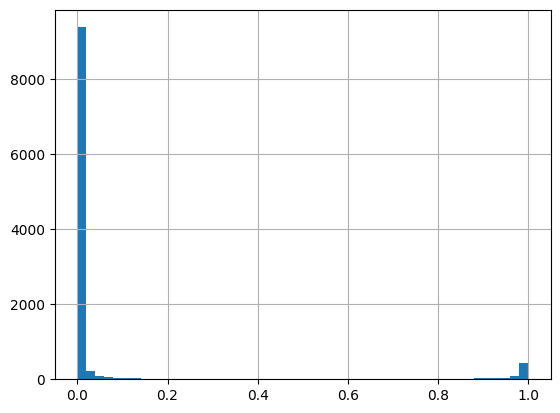

In [ ]:
posts_clean["deberta_score"].hist(
    bins=50
)

In [ ]:
len(posts_clean)
posts_clean.head(1)

,post_id,title,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date,permalink,url,post_text,deberta_score,is_real_estate,prediction
0,1t0d0ph,Average DEWA in Springs (Type 4M),Whats an average DEWA for a Type 4M in Springs ?,Timely_Raisin129,dubai,0,0.5,2,2026-04-30 23:49:25+00:00,/r/dubai/comments/1t0d0ph/average_dewa_in_spri...,https://www.reddit.com/r/dubai/comments/1t0d0p...,Average DEWA in Springs (Type 4M) Whats an ave...,0.012147,0,0


In [ ]:
posts_clean.to_csv(
    "/content/drive/MyDrive/Dubai_Real_Estate_Data/Prajwal final reddit/dubai_posts_deberta.csv",
    index=False
)

In [ ]:
# Keep only posts classified as real estate
real_estate_posts = posts_clean[
    posts_clean["is_real_estate"] == 1
].copy()

print("Number of real estate posts:", len(real_estate_posts))

Number of real estate posts: 825


In [ ]:
real_estate_posts.to_csv(
    "/content/drive/MyDrive/Dubai_Real_Estate_Data/Prajwal final reddit/dubai_posts_realestate_only.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


POSTS AND COMMENTS

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Dubai_Real_Estate_Data/Prajwal final reddit/"
posts = pd.read_csv(f"{file_path}/dubai_posts_realestate_only.csv", low_memory=False)
comments  = pd.read_csv(f"{file_path}/dubai_comments.csv", low_memory=False)

In [ ]:
posts.head()

,post_id,title,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date,permalink,url,post_text,deberta_score,is_real_estate,prediction
0,1t083qk,How can I check if my landlord re-rented my ap...,I was recently evicted from my apartment becau...,Grand_Company1676,dubai,2,0.75,3,2026-04-30 20:31:20+00:00,/r/dubai/comments/1t083qk/how_can_i_check_if_m...,https://www.reddit.com/r/dubai/comments/1t083q...,How can I check if my landlord re-rented my ap...,0.993985,1,1
1,1t033ao,Would you prefer a smaller location with minim...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...,0.993229,1,1
2,1t007iw,Is now a good time to buy an apartment in Dubai?,Im looking to buy a studio or a one bedroom ap...,Original-Conflict763,dubai,1,0.67,1,2026-04-30 15:49:49+00:00,/r/dubai/comments/1t007iw/is_now_a_good_time_t...,https://www.reddit.com/r/dubai/comments/1t007i...,Is now a good time to buy an apartment in Duba...,0.999369,1,1
3,1szrsww,Damage to flat between MoU signing and transfer,Hi! I’m possibly buying an apartment in Dubai ...,Andrea-World92,dubai,0,0.50,13,2026-04-30 10:07:49+00:00,/r/dubai/comments/1szrsww/damage_to_flat_betwe...,https://www.reddit.com/r/dubai/comments/1szrsw...,Damage to flat between MoU signing and transfe...,0.999537,1,1
4,1szq9do,Are chiller charge increases regulated in Duba...,"Hi everyone,\n\nI need some advice regarding m...",dreamingdna73,dubai,3,0.64,4,2026-04-30 08:38:24+00:00,/r/dubai/comments/1szq9do/are_chiller_charge_i...,https://www.reddit.com/r/dubai/comments/1szq9d...,Are chiller charge increases regulated in Duba...,0.982440,1,1


In [ ]:
comments.head()

,comment_id,post_id,parent_id,body,comment_author,comment_score,date,permalink,controversiality,is_submitter
0,oj85tey,1t0cvwd,t3_1t0cvwd,What type of items do you ship,OmarLeGrand,1,2026-04-30 23:49:18+00:00,/r/dubai/comments/1t0cvwd/business_owners_what...,0,False
1,oj85g94,1s2k436,t3_1s2k436,Same query. And almost same category. Let me k...,Flimsy_Technician156,1,2026-04-30 23:47:11+00:00,/r/dubai/comments/1s2k436/can_an_abudhabi_resi...,0,False
2,oj84lze,1sywz52,t3_1sywz52,Recurrent theme: Dubai is glamorous to vacatio...,Joaquin_amazing,1,2026-04-30 23:42:23+00:00,/r/dubai/comments/1sywz52/quit_my_job_yesterda...,0,False
3,oj8305g,1sww74n,t3_1sww74n,"heard in al furjan, 2 minutes ago, very very l...",Mesredi,-2,2026-04-30 23:33:11+00:00,/r/dubai/comments/1sww74n/ceasefireattacks_meg...,1,False
4,oj82cg7,1szo2gg,t1_oj5ynas,And that's with taxed money too. Equivalent is...,beleagueredd,1,2026-04-30 23:29:25+00:00,/r/dubai/comments/1szo2gg/uae_petrol_diesel_pr...,0,False


In [ ]:
# Keep required columns
posts_c = posts[[
    "post_id",
    "title",
    "selftext",
    "post_author",
    "subreddit",
    "post_score",
    "upvote_ratio",
    "num_comments",
    "date",
    "permalink",
    "url",
    "post_text"
]]

comments_c = comments[[
    "comment_id",
    "post_id",
    "parent_id",
    "body",
    "comment_author",
    "comment_score",
    "date",
    "permalink",
    "controversiality",
    "is_submitter"
]]

# Merge comments with their parent posts
df = comments_c.merge(
    posts_c,
    on="post_id",
    how="inner",
    suffixes=("_comment", "_post")
)

print(f"Posts: {len(posts_c):,}")
print(f"Comments: {len(comments_c):,}")
print(f"Matched comment-post pairs: {len(df):,}")
print(f"Unmatched comments: {len(comments_c) - len(df):,}")

df.head()

Posts: 825
Comments: 261,456
Matched comment-post pairs: 9,208
Unmatched comments: 252,248


,comment_id,post_id,parent_id,body,comment_author,comment_score,date_comment,permalink_comment,controversiality,is_submitter,...,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date_post,permalink_post,url,post_text
0,oj76omq,1t083qk,t3_1t083qk,Have you still got a copy of your ejari? Try s...,ElSocio87,2,2026-04-30 20:38:03+00:00,/r/dubai/comments/1t083qk/how_can_i_check_if_m...,0,False,...,I was recently evicted from my apartment becau...,Grand_Company1676,dubai,2,0.75,3,2026-04-30 20:31:20+00:00,/r/dubai/comments/1t083qk/how_can_i_check_if_m...,https://www.reddit.com/r/dubai/comments/1t083q...,How can I check if my landlord re-rented my ap...
1,oj6sic3,1sytz8g,t1_oj3wh0p,Check with DED and RERA,Tough_Emu3927,1,2026-04-30 19:31:00+00:00,/r/dubai/comments/1sytz8g/my_landlord_removed_...,0,False,...,Hello. I am writing really really upset. I hav...,Potential-Sky5855,dubai,17,0.74,33,2026-04-29 09:39:32+00:00,/r/dubai/comments/1sytz8g/my_landlord_removed_...,https://www.reddit.com/r/dubai/comments/1sytz8...,My landlord removed my staff while I was aboar...
2,oj6h2ca,1t033ao,t3_1t033ao,Dubai over Sharjah any day.,Tasty-Reception176,1,2026-04-30 18:37:59+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,False,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...
3,oj6f9dz,1t033ao,t1_oj6exs4,"I live in suyouh, I know exactly the road your...",ze_crazy_cat_lady,2,2026-04-30 18:29:43+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,True,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...
4,oj6exs4,1t033ao,t1_oj6e7wz,"muhaisnah's okay too, the key thing is it shou...",Capable-Estate8851,2,2026-04-30 18:28:16+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,False,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...


In [ ]:
comments_per_post = (
    comments
    .groupby("post_id")
    .size()
    .reset_index(name="actual_num_comments")
)

comments_per_post.head()

,post_id,actual_num_comments
0,1lt3cso,1
1,1lvkox8,1
2,1lx70ry,1
3,1lx8y11,1
4,1lxhjkd,1


In [ ]:
len(df)

9208

In [ ]:
comments_per_post = (
    df.groupby("post_id")
      .size()
      .reset_index(name="comment_count")
      .sort_values("comment_count", ascending=False)
)

comments_per_post.head(20)

,post_id,comment_count
591,1sns12d,169
213,1qz3b6y,137
562,1sk6smh,128
426,1rxw3ww,125
544,1shjcum,124
363,1rnyjv1,122
224,1r06zvp,102
370,1rp3k0n,102
101,1qhphqx,93
511,1sc97br,86


In [ ]:
df.head()

,comment_id,post_id,parent_id,body,comment_author,comment_score,date_comment,permalink_comment,controversiality,is_submitter,...,selftext,post_author,subreddit,post_score,upvote_ratio,num_comments,date_post,permalink_post,url,post_text
0,oj76omq,1t083qk,t3_1t083qk,Have you still got a copy of your ejari? Try s...,ElSocio87,2,2026-04-30 20:38:03+00:00,/r/dubai/comments/1t083qk/how_can_i_check_if_m...,0,False,...,I was recently evicted from my apartment becau...,Grand_Company1676,dubai,2,0.75,3,2026-04-30 20:31:20+00:00,/r/dubai/comments/1t083qk/how_can_i_check_if_m...,https://www.reddit.com/r/dubai/comments/1t083q...,How can I check if my landlord re-rented my ap...
1,oj6sic3,1sytz8g,t1_oj3wh0p,Check with DED and RERA,Tough_Emu3927,1,2026-04-30 19:31:00+00:00,/r/dubai/comments/1sytz8g/my_landlord_removed_...,0,False,...,Hello. I am writing really really upset. I hav...,Potential-Sky5855,dubai,17,0.74,33,2026-04-29 09:39:32+00:00,/r/dubai/comments/1sytz8g/my_landlord_removed_...,https://www.reddit.com/r/dubai/comments/1sytz8...,My landlord removed my staff while I was aboar...
2,oj6h2ca,1t033ao,t3_1t033ao,Dubai over Sharjah any day.,Tasty-Reception176,1,2026-04-30 18:37:59+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,False,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...
3,oj6f9dz,1t033ao,t1_oj6exs4,"I live in suyouh, I know exactly the road your...",ze_crazy_cat_lady,2,2026-04-30 18:29:43+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,True,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...
4,oj6exs4,1t033ao,t1_oj6e7wz,"muhaisnah's okay too, the key thing is it shou...",Capable-Estate8851,2,2026-04-30 18:28:16+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,0,False,...,"I'm in Sharjah right now, thinking about movin...",ze_crazy_cat_lady,dubai,2,0.63,7,2026-04-30 17:32:13+00:00,/r/dubai/comments/1t033ao/would_you_prefer_a_s...,https://www.reddit.com/r/dubai/comments/1t033a...,Would you prefer a smaller location with minim...


In [ ]:
# Get the post IDs of the real-estate posts
real_estate_post_ids = set(posts["post_id"])

# Keep only comments belonging to those posts
real_estate_comments = comments[
    comments["post_id"].isin(real_estate_post_ids)
].copy()

print("Posts:", len(posts))
print("Comments:", len(real_estate_comments))

Posts: 825
Comments: 9208


In [ ]:
df.to_csv(f"{file_path}/dubai_postscomments_realestate.csv", index=False)

In [ ]:
len(real_estate_comments)

9208

In [ ]:
real_estate_comments.to_csv(
    f"{file_path}/dubai_comments_realestate_only.csv",
    index=False
)